# ElasticNet Model Explanation

## What is ElasticNet?

**ElasticNet Regression** combines:

* **L1 Regularization (Lasso)**
* **L2 Regularization (Ridge)**

The cost function:

$$
Loss = RSS + \alpha (\lambda_1 ||w||_1 + \lambda_2 ||w||_2^2)
$$

Where:

* **L1 penalty → Feature selection**
* **L2 penalty → Weight shrinkage**

ElasticNet solves problems where **Lasso or Ridge alone are not optimal**.


# When to Use ElasticNet

Use ElasticNet when:


- 1️. Dataset has **many correlated features**
- 2️. **Feature selection** is needed
- 3️. You want **regularization to prevent overfitting**
- 4️. High dimensional data (many feature


Common applications:

* Finance prediction
* Housing price prediction
* Medical datasets
* Marketing analytics


#  Advantages

- 1️.Combines L1 and L2 benefits
    * Feature selection + regularization
- 2️. Handles multicollinearity well
- 3. Works well for high dimensional datasets
- 4. More stable than Lasso when features are correlated



# Disadvantages

```
1️. Requires hyperparameter tuning
Two parameters must be tuned:

* `alpha`
* `l1_ratio`

2️.Requires feature scaling
3️. Less interpretable than simple linear regression

```

# ⚙️ Important Hyperparameters

### 1️. `alpha`

Controls **regularization strength**

* Higher → stronger regularization
* Lower → less regularization

Typical range:

```
0.001 – 10
```


### 2️. `l1_ratio`

Controls **L1 vs L2 mix**

| Value | Behavior   |
| ----- | ---------- |
| 0     | Pure Ridge |
| 1     | Pure Lasso |
| 0.5   | Equal mix  |


# Practical Tuning Tips

### Tip 1

Always **scale features** before ElasticNet.

```
StandardScaler
```


### Tip 2

Tune these parameters together:

```
alpha
l1_ratio
```


### Tip 3

Use **cross-validation**

```
GridSearchCV
RandomizedSearchCV
```


### Tip 4

Start with wide ranges

```
alpha: [0.001, 0.01, 0.1, 1, 10]
l1_ratio: [0.1,0.3,0.5,0.7,0.9]
```


### Tip 5

Use **Pipeline** to prevent data leakage.


#  Summary

ElasticNet is a **powerful regularized regression model** that combines:

* Ridge regression stability
* Lasso feature selection

It works best when:

* Features are correlated
* Dataset is high dimensional
* Overfitting is possible



**Importing Libraries**

In [1]:
# Basic libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn utilities
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Model
from sklearn.linear_model import ElasticNet

# Metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

**Load dataset**

In [2]:
# Load California Housing dataset
data = fetch_california_housing()

In [3]:
# Convert to DataFrame
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="Target")

# Preview data
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


**Exploratory Data Analysis (EDA)**

In [4]:
# Dataset shape
print("Dataset shape:", X.shape)

# Summary statistics
X.describe()

Dataset shape: (20640, 8)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


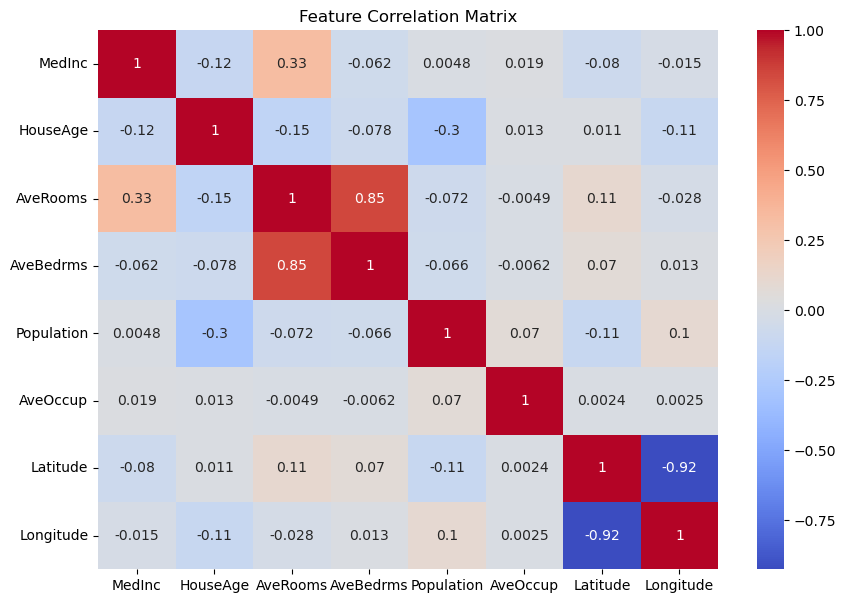

In [5]:
plt.figure(figsize=(10,7))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

**Data Cleaning**

In [6]:
# Check missing values
X.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

In [7]:
# Fill missing values
X = X.fillna(X.mean())

**Feature Engineering**

ElasticNet requires scaled features because it is sensitive to feature magnitude.

We will use StandardScaler.

**Train-Test Split**

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [9]:
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (16512, 8)
Test set size: (4128, 8)


**Model Pipeline**

In [10]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet())
])

**Hyperparameter Tuning with GridSearchCV**

In [11]:
param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10],
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'model__alpha': 0.001, 'model__l1_ratio': 0.9}
Best Score: 0.6114857546927948


**Train Final Model**

In [12]:
best_model = grid.best_estimator_

best_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', ElasticNet(alpha=0.001, l1_ratio=0.9))])

**Model Prediction**

In [13]:
# Predictions
y_pred = best_model.predict(X_test)

**Model Evaluation**

In [14]:
# Regression Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [15]:
print("Evaluation Metrics:")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

Evaluation Metrics:
MSE : 0.5545735169489011
RMSE: 0.7446969295954571
MAE : 0.5331401292515605
R2  : 0.5767935612793467


**Feature Importance**

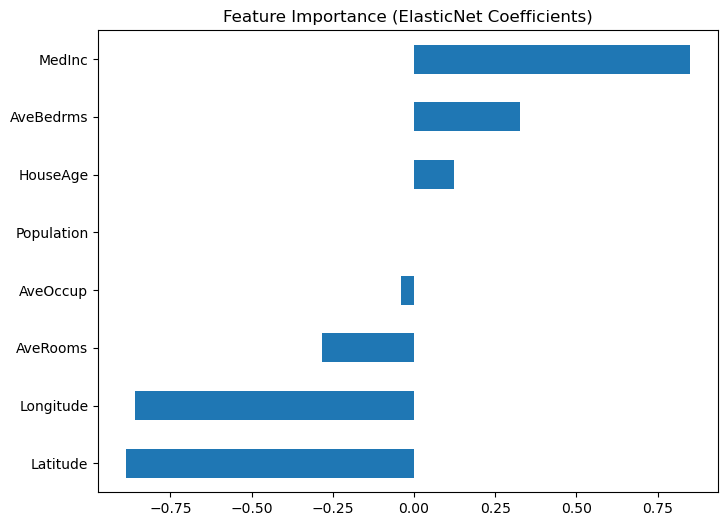

In [16]:
coefficients = pd.Series(
    best_model.named_steps["model"].coef_,
    index=X.columns
)

coefficients.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Feature Importance (ElasticNet Coefficients)")
plt.show()

**Prediction vs Actual Visualization**

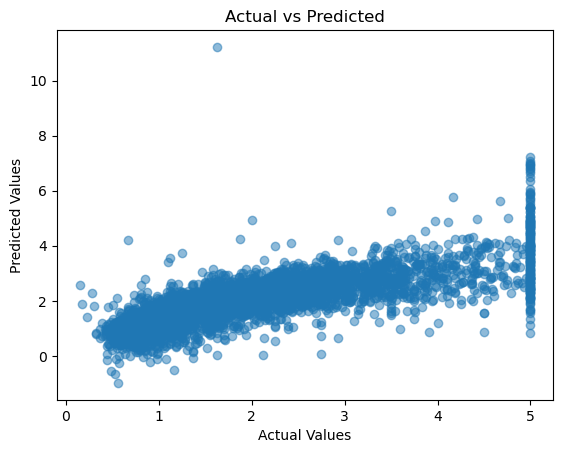

In [17]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

**Learning Curve**

In [18]:
train_sizes, train_scores, test_scores = learning_curve(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

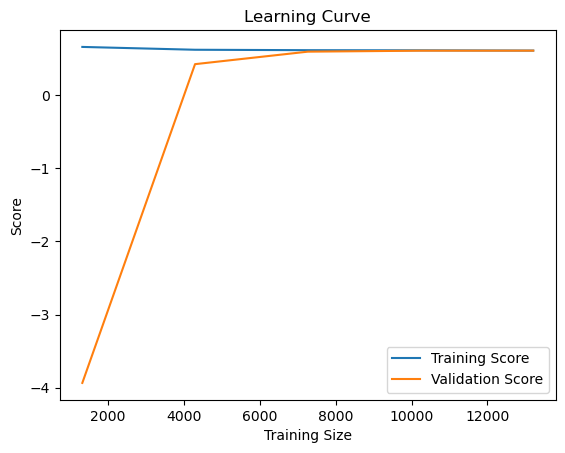

In [19]:
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")

plt.xlabel("Training Size")
plt.ylabel("Score")
plt.title("Learning Curve")
plt.legend()
plt.show()